<a href="https://colab.research.google.com/github/iamviplavkr/viplav_kumar_23FE10CSE00421_ML/blob/main/LAB_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [3]:
# Step 2: Load dataset
data = pd.read_csv("/content/housing.csv")

# View data
print(data.head())
print(data.info())

   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0       79545.45857             5.682861                   7.009188   
1       79248.64245             6.002900                   6.730821   
2       61287.06718             5.865890                   8.512727   
3       63345.24005             7.188236                   5.586729   
4       59982.19723             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09      23086.80050  1.059034e+06   
1                          3.09      40173.07217  1.505891e+06   
2                          5.13      36882.15940  1.058988e+06   
3                          3.26      34310.24283  1.260617e+06   
4                          4.23      26354.10947  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kathleen, CA...  
2  9127 Eli

In [6]:
# Step 3: Remove non-numeric columns
# Keep only numeric columns
numeric_data = data.select_dtypes(include=[np.number])


In [7]:
# Optional: check removed columns
print("Removed columns:", set(data.columns) - set(numeric_data.columns))

# Step 4: Handle missing values
numeric_data = numeric_data.dropna()


Removed columns: {'Address'}


In [8]:
# Step 5: Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

print("Scaling successful")

Scaling successful


In [9]:
# Step 5: Elbow Method to find optimal K
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

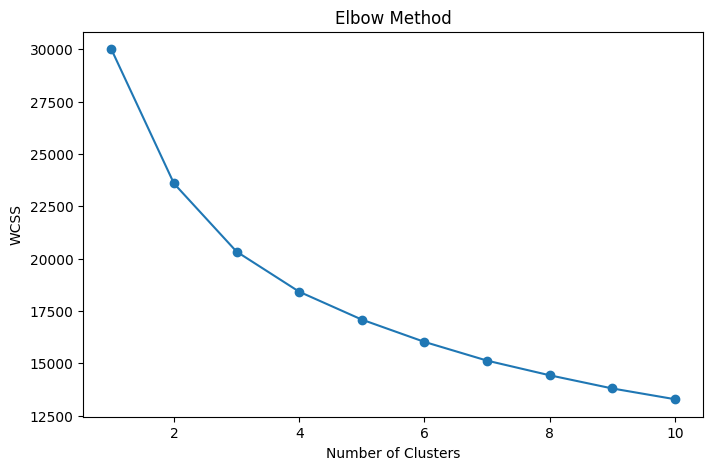

In [10]:
# Plot Elbow Graph
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [11]:
# Step 6: Apply K-Means (choose optimal k, e.g., 4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(scaled_data)


In [12]:
# Add cluster labels to dataset
data['Cluster'] = clusters

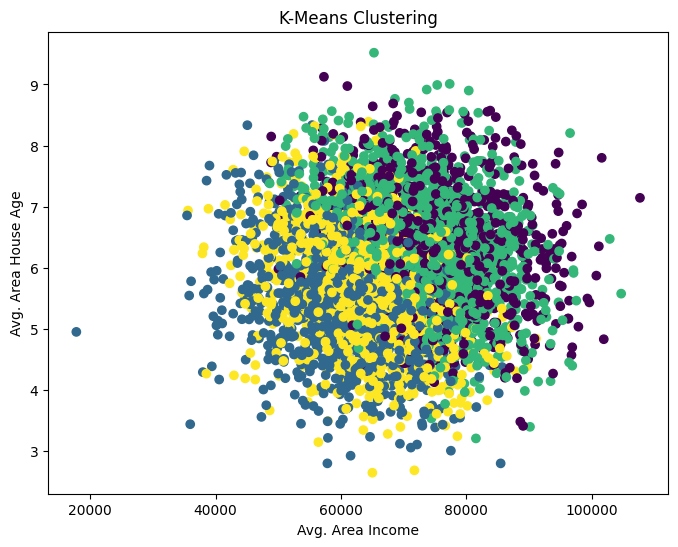

In [14]:
# Pick first two numeric columns
cols = numeric_data.columns

plt.figure(figsize=(8,6))
plt.scatter(numeric_data[cols[0]], numeric_data[cols[1]], c=clusters, cmap='viridis')
plt.xlabel(cols[0])
plt.ylabel(cols[1])
plt.title("K-Means Clustering")
plt.show()

In [15]:
# Step 8: Cluster Centers
print("Cluster Centers (scaled):")
print(kmeans.cluster_centers_)

Cluster Centers (scaled):
[[ 0.66431418  0.43215227  0.8536538   0.59459836  0.55060769  1.20966216]
 [-0.7410747  -0.54114653 -0.68704586 -0.58891643 -0.38679232 -1.18366806]
 [ 0.45257848  0.34191987 -0.67136513 -0.62621622  0.20008863  0.31918626]
 [-0.4191235  -0.27632135  0.77779664  0.84420591 -0.34315201 -0.2882595 ]]


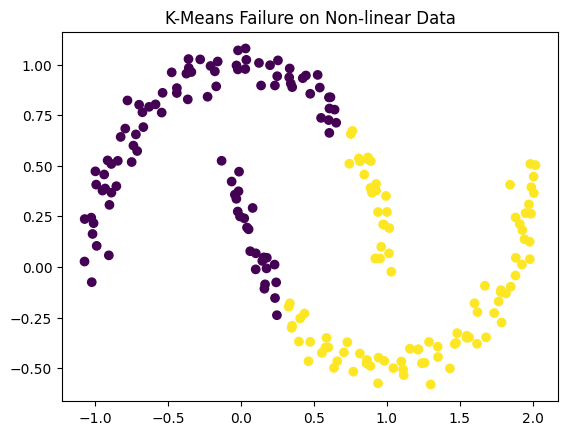

In [17]:
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_moons(200, noise=0.05, random_state=0)

labels = KMeans(2).fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("K-Means Failure on Non-linear Data")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


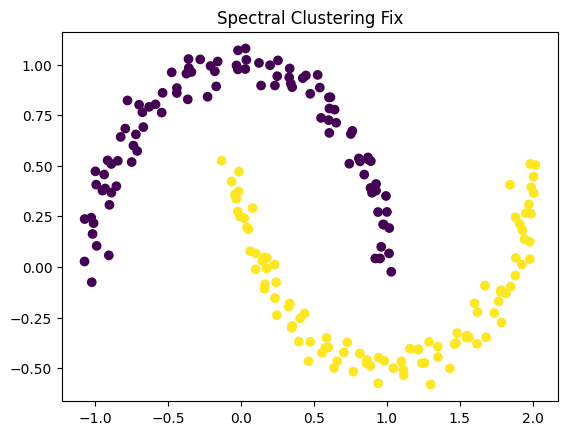

In [18]:
from sklearn.cluster import SpectralClustering

model = SpectralClustering(
    n_clusters=2,
    affinity='nearest_neighbors',
    assign_labels='kmeans'
)

labels = model.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("Spectral Clustering Fix")
plt.show()